In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, TimeDistributed, LSTM
import time
from datetime import datetime
from tensorflow import keras
import random
import numpy as np
import cv2
import os


In [2]:
# import os
# import cv2

# TRAIN_DIR = r"C:\Users\Shubham\Downloads\Detection-of-Violent-Scenes-in-Cartoon-Movies-main (1)\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train"

# def video_to_clip_frames(video_path, out_dir, max_frames=24):
#     os.makedirs(out_dir, exist_ok=True)
#     cap = cv2.VideoCapture(video_path)

#     if not cap.isOpened():
#         print("Cannot open:", video_path)
#         return 0
# 
#     i = 0
#     while True:
#         ret, frame = cap.read()
#         if not ret or i >= max_frames:
#             break

#         frame = cv2.resize(frame, (224, 224))
#         cv2.imwrite(os.path.join(out_dir, f"frame_{i:04d}.jpg"), frame)
#         i += 1

#     cap.release()
#     return i


# # Go inside each class folder
# for cls in os.listdir(TRAIN_DIR):
#     cls_path = os.path.join(TRAIN_DIR, cls)

#     if not os.path.isdir(cls_path):
#         continue

#     videos = [v for v in os.listdir(cls_path)
#               if v.lower().endswith((".mp4", ".avi", ".mov", ".mkv"))]

#     for idx, v in enumerate(videos, start=1):
#         vpath = os.path.join(cls_path, v)
#         clip_folder = os.path.join(cls_path, f"clip_{idx:04d}")

#         n = video_to_clip_frames(vpath, clip_folder)
#         print(cls, v, "-> frames:", n)

In [3]:
# import os
# import cv2

# TEST_DIR = r"C:\Users\Shubham\Downloads\Detection-of-Violent-Scenes-in-Cartoon-Movies-main (1)\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\test"

# def video_to_clip_frames(video_path, out_dir, max_frames=24):
#     os.makedirs(out_dir, exist_ok=True)
#     cap = cv2.VideoCapture(video_path)

#     if not cap.isOpened():
#         print("Cannot open:", video_path)
#         return 0

#     i = 0
#     while True:
#         ret, frame = cap.read()
#         if not ret or i >= max_frames:
#             break

#         frame = cv2.resize(frame, (224, 224))
#         cv2.imwrite(os.path.join(out_dir, f"frame_{i:04d}.jpg"), frame)
#         i += 1

#     cap.release()
#     return i


# # Convert test videos
# for cls in os.listdir(TEST_DIR):
#     cls_path = os.path.join(TEST_DIR, cls)

#     if not os.path.isdir(cls_path):
#         continue

#     videos = [v for v in os.listdir(cls_path)
#               if v.lower().endswith((".mp4", ".avi", ".mov", ".mkv"))]

#     for idx, v in enumerate(videos, start=1):
#         vpath = os.path.join(cls_path, v)
#         clip_folder = os.path.join(cls_path, f"clip_{idx:04d}")

#         n = video_to_clip_frames(vpath, clip_folder)
#         print(cls, v, "-> frames:", n)

In [4]:
import os

# =========================================================
# Define BASE directory (only change this if needed)
# =========================================================

BASE_DIR = r"C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main"

TRAIN_DIR = os.path.join(BASE_DIR, "video_dataset", "custom-videos-dataset", "train")
VAL_DIR   = os.path.join(BASE_DIR, "video_dataset", "custom-videos-dataset", "test")  # using test as validation

# =========================================================
# Verify paths exist (VERY IMPORTANT)
# =========================================================

if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(f"TRAIN_DIR not found: {TRAIN_DIR}")

if not os.path.exists(VAL_DIR):
    raise FileNotFoundError(f"VAL_DIR not found: {VAL_DIR}")

print("Train folder found")
print("Val/Test folder found")

# =========================================================
# Detect classes automatically from TRAIN folder
# =========================================================

class_names = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])

print("Detected classes:", class_names)

class_to_idx = {c: i for i, c in enumerate(class_names)}


# Function to collect clip folders and labels

def get_clip_dirs_and_labels(root_dir):
    video_dirs, labels = [], []

    for cls in class_names:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.exists(cls_dir):
            continue

        for clip in sorted(os.listdir(cls_dir)):
            clip_dir = os.path.join(cls_dir, clip)

            if os.path.isdir(clip_dir):
                video_dirs.append(clip_dir)
                labels.append(class_to_idx[cls])

    return video_dirs, labels

#Build dataset lists

train_video_dirs, train_labels = get_clip_dirs_and_labels(TRAIN_DIR)
val_video_dirs, val_labels     = get_clip_dirs_and_labels(VAL_DIR)

print("Train clips:", len(train_video_dirs))
print("Val clips:", len(val_video_dirs))

Train folder found
Val/Test folder found
Detected classes: ['bloody', 'explosions', 'fight', 'gun shot', 'non-violence', 'violence']
Train clips: 372
Val clips: 30


In [5]:
import os

print("TRAIN_DIR:", TRAIN_DIR)
print("TRAIN exists?", os.path.exists(TRAIN_DIR))

if os.path.exists(TRAIN_DIR):
    print("TRAIN folders:", os.listdir(TRAIN_DIR))

print("\nVAL_DIR:", VAL_DIR)
print("VAL exists?", os.path.exists(VAL_DIR))

if os.path.exists(VAL_DIR):
    print("VAL folders:", os.listdir(VAL_DIR))

TRAIN_DIR: C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train
TRAIN exists? True
TRAIN folders: ['bloody', 'explosions', 'fight', 'gun shot', 'non-violence', 'violence']

VAL_DIR: C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\test
VAL exists? True
VAL folders: ['bloody', 'explosions', 'fight', 'gun shot', 'non-violence', 'violence']


In [6]:
import math

steps_per_epoch = math.ceil(len(train_video_dirs) / 32)
val_steps = math.ceil(len(val_video_dirs) / 32)

print("Steps per epoch:", steps_per_epoch)
print("Validation steps:", val_steps)

Steps per epoch: 12
Validation steps: 1


In [7]:
def video_generator(video_dirs, labels,
                    batch_size, frames, num_classes,
                    shuffle=True, random_clip=True):

    while True:

        X, Y = [], []

        # Shuffle video order
        if shuffle:
            np.random.shuffle(video_dirs)

        for i in range(batch_size):

            video_path = video_dirs[i % len(video_dirs)]

            all_frames = sorted(os.listdir(video_path))

            if len(all_frames) < frames:
                continue

            # FRAME SELECTION
            if random_clip:
                start = np.random.randint(0, len(all_frames) - frames + 1)
                selected_frames = all_frames[start:start + frames]
            else:
                selected_frames = all_frames[:frames]

            frame_seq = []

            for f in selected_frames:
                img = cv2.imread(os.path.join(video_path, f))
                img = cv2.resize(img, (224, 224))
                img = img / 255.0
                frame_seq.append(img)

            X.append(frame_seq)

            # one-hot label (if needed)
            label = labels[video_dirs.index(video_path)]
            y = tf.keras.utils.to_categorical(label, num_classes)
            Y.append(y)
        yield np.array(X), np.array(Y)

In [8]:
num_classes = 6   # 'bloody', 'explosions', 'fight', 'gun shot', 'non-violence', 'violence'
batch_size = 4
frame_sequence = 16

In [9]:
from tensorflow.keras import layers, models

input_shape = (16, 224, 224, 3)

model = models.Sequential()

model.add(layers.TimeDistributed(
    layers.Conv2D(32, (3,3), activation='relu'),
    input_shape=input_shape
))

model.add(layers.TimeDistributed(layers.MaxPooling2D(2,2)))

model.add(layers.TimeDistributed(layers.Conv2D(64, (3,3), activation='relu')))
model.add(layers.TimeDistributed(layers.MaxPooling2D(2,2)))

model.add(layers.TimeDistributed(layers.Flatten()))

model.add(layers.LSTM(128))

model.add(layers.Dense(6, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDistr  (None, 16, 222, 222, 32)  896      
 ibuted)                                                         
                                                                 
 time_distributed_1 (TimeDis  (None, 16, 111, 111, 32)  0        
 tributed)                                                       
                                                                 
 time_distributed_2 (TimeDis  (None, 16, 109, 109, 64)  18496    
 tributed)                                                       
                                                                 
 time_distributed_3 (TimeDis  (None, 16, 54, 54, 64)   0         
 tributed)                                                       
                                                                 
 time_distributed_4 (TimeDis  (None, 16, 186624)       0

In [10]:
opt = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=opt,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
import os
import cv2
import numpy as np

# ==============================
# SET TEST ROOT PATH
# ==============================

test_root = r"C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\test"

frames = 16
num_classes = 6   # change if different

# ==============================
# FIND FIRST CLIP AUTOMATICALLY
# ==============================

class_folders = os.listdir(test_root)

selected_clip_path = None

for class_name in class_folders:
    class_path = os.path.join(test_root, class_name)
    
    if os.path.isdir(class_path):
        clip_folders = os.listdir(class_path)
        
        if len(clip_folders) > 0:
            selected_clip_path = os.path.join(class_path, clip_folders[0])
            print("Using clip:", selected_clip_path)
            break

if selected_clip_path is None:
    raise ValueError("No clip folders found in test directory.")

# ==============================
# LOAD FRAMES
# ==============================

frame_files = sorted(os.listdir(selected_clip_path))[:frames]

frames_data = []

for f in frame_files:
    img_path = os.path.join(selected_clip_path, f)
    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.resize(img, (224, 224))
    img = img.astype("float32") / 255.0
    frames_data.append(img)

if len(frames_data) < frames:
    raise ValueError("Not enough frames found in clip.")

sequence = np.expand_dims(np.array(frames_data), axis=0)

print("Input shape:", sequence.shape)

# ==============================
# PREDICT
# ==============================

pred = model.predict(sequence)
if pred.ndim == 3:
    avg_pred = np.mean(pred, axis=1)
else:
    avg_pred = pred

predicted_class = np.argmax(avg_pred, axis=1)[0]

print("Probabilities:", avg_pred)
print("Predicted class index:", predicted_class)

Using clip: C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\test\non-violence\clip_0001
Input shape: (1, 16, 224, 224, 3)
1/1 [==============================] - 1s 947ms/step
Probabilities: [[0.16427672 0.18282405 0.15496139 0.15436378 0.1686897  0.17488432]]
Predicted class index: 1


In [12]:
model.optimizer

In [13]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

# =========================
# CONFIG
# =========================
BATCH_SIZE = 16
FRAMES = 16

# =========================
# STEPS
# =========================
steps_per_epoch = len(train_video_dirs) // BATCH_SIZE
validation_steps = len(val_video_dirs) // BATCH_SIZE

# =========================
# GENERATORS
# =========================
train_gen = video_generator(
    train_video_dirs,
    train_labels,
    batch_size=BATCH_SIZE,
    frames=FRAMES,
    num_classes=num_classes,
    shuffle=True,
    random_clip=True
)

val_gen = video_generator(
    val_video_dirs,
    val_labels,
    batch_size=BATCH_SIZE,
    frames=FRAMES,
    num_classes=num_classes,
    shuffle=False,
    random_clip=False
)

# =========================
# MODEL COMPILE
# =========================
opt = tf.keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=opt,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# =========================
# CALLBACK
# =========================
early = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

# =========================
# TRAIN
# =========================
history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=30,
    validation_data=val_gen,
    validation_steps=validation_steps,
    callbacks=[early],
    verbose=1
)

Epoch 1/30
23/23 [==============================] - 193s 8s/step - loss: 0.0861 - accuracy: 0.9592 - val_loss: 8.7621 - val_accuracy: 0.0000e+00
Epoch 2/30
23/23 [==============================] - 180s 8s/step - loss: 0.0011 - accuracy: 1.0000 - val_loss: 9.6313 - val_accuracy: 0.0000e+00
Epoch 3/30
23/23 [==============================] - 170s 7s/step - loss: 7.6767e-04 - accuracy: 1.0000 - val_loss: 9.9957 - val_accuracy: 0.0000e+00
Epoch 4/30
23/23 [==============================] - 168s 7s/step - loss: 4.2333e-04 - accuracy: 1.0000 - val_loss: 10.2269 - val_accuracy: 0.0000e+00


In [14]:

class_names = ['bloody', 'explosions', 'fight', 'gun shot', 'non-violence', 'violence']
print("Predicted Class:", class_names[predicted_class])


Predicted Class: explosions


In [15]:
print(model.input_shape)

(None, 16, 224, 224, 3)


In [16]:

from keras.callbacks import ModelCheckpoint
# define checkpoint callback
filepath = 'saved_models/model-ep{epoch:02d}-loss{loss:.3f}-val_loss{val_loss:.3f}.h5'
checkpoint = ModelCheckpoint(filepath, monitor='val_loss', verbose=1, save_best_only=False, mode='min')

In [17]:
#enter the weights of the model from where you start resuming incase the training is not going to be completed in one pass
#model.load_weights('saved_models/model-ep50-loss0.306-val_loss0.235.h5')

In [18]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

TRAIN_DIR = "violent_scene_dataset/train"   # your training folder
VAL_DIR = "violent_scene_dataset/val"       # your validation folder


In [19]:
#Defines your main project folder
import os

BASE_DIR = r"C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main"

TRAIN_DIR = os.path.join(BASE_DIR, "video_dataset", "custom-videos-dataset", "train")
VAL_DIR   = os.path.join(BASE_DIR, "video_dataset", "custom-videos-dataset", "test")

print("TRAIN exists?", os.path.exists(TRAIN_DIR))
print("VAL exists?", os.path.exists(VAL_DIR))

TRAIN exists? True
VAL exists? True


In [20]:
import os

# Automatically detect classes from train folder
class_names = sorted(os.listdir(TRAIN_DIR))
print("Detected classes:", class_names)

class_to_idx = {c:i for i,c in enumerate(class_names)}

def get_clip_dirs_and_labels(root_dir):
    video_dirs, labels = [], []
    for cls in class_names:
        cls_dir = os.path.join(root_dir, cls)
        if not os.path.exists(cls_dir):
            continue
        for clip in sorted(os.listdir(cls_dir)):
            clip_dir = os.path.join(cls_dir, clip)
            if os.path.isdir(clip_dir):
                video_dirs.append(clip_dir)
                labels.append(class_to_idx[cls])
    return video_dirs, labels

train_video_dirs, train_labels = get_clip_dirs_and_labels(TRAIN_DIR)
val_video_dirs, val_labels = get_clip_dirs_and_labels(VAL_DIR)

print("Train clips:", len(train_video_dirs))
print("Val clips:", len(val_video_dirs))

Detected classes: ['bloody', 'explosions', 'fight', 'gun shot', 'non-violence', 'violence']
Train clips: 372
Val clips: 30


In [21]:
import os

def inspect_clips(video_dirs, n=20):
    for d in video_dirs[:n]:
        files = [f for f in os.listdir(d) if f.lower().endswith((".jpg",".jpeg",".png"))]
        print(d, "frames:", len(files))
inspect_clips(train_video_dirs, n=20)



C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\bloody\clip_0001 frames: 24
C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\bloody\clip_0002 frames: 24
C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\bloody\clip_0003 frames: 24
C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\bloody\clip_0004 frames: 24
C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\bloody\clip_0005 frames: 24
C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\bloody\clip_0006 frames: 24
C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\bloody\clip_0007 frames: 24
C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\bloody\clip_0008 frames: 24
C:\Detec

In [22]:
x_test, y_test = next(video_generator(train_video_dirs, train_labels,
                                      batch_size=1, frames=16, num_classes=6))

print("X shape:", x_test.shape)
print("Y shape:", y_test.shape)

X shape: (1, 16, 224, 224, 3)
Y shape: (1, 6)


In [23]:
import os
import cv2
import numpy as np

# ==============================
# SET TEST ROOT PATH
# ==============================

test_root = r"C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\test"

frames = 16
num_classes = 6   # change if different

# ==============================
# FIND FIRST CLIP AUTOMATICALLY
# ==============================

class_folders = os.listdir(test_root)

selected_clip_path = None

for class_name in class_folders:
    class_path = os.path.join(test_root, class_name)
    
    if os.path.isdir(class_path):
        clip_folders = os.listdir(class_path)
        
        if len(clip_folders) > 0:
            selected_clip_path = os.path.join(class_path, clip_folders[0])
            print("Using clip:", selected_clip_path)
            break

if selected_clip_path is None:
    raise ValueError("No clip folders found in test directory.")

# ==============================
# LOAD FRAMES
# ==============================

frame_files = sorted(os.listdir(selected_clip_path))[:frames]

frames_data = []

for f in frame_files:
    img_path = os.path.join(selected_clip_path, f)
    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.resize(img, (224, 224))
    img = img.astype("float32") / 255.0
    frames_data.append(img)

if len(frames_data) < frames:
    raise ValueError("Not enough frames found in clip.")

sequence = np.expand_dims(np.array(frames_data), axis=0)

print("Input shape:", sequence.shape)

# ==============================
# PREDICT
# ==============================

pred = model.predict(sequence)
if pred.ndim == 3:
    avg_pred = np.mean(pred, axis=1)
else:
    avg_pred = pred

predicted_class = np.argmax(avg_pred, axis=1)[0]

print("Probabilities:", avg_pred)
print("Predicted class index:", predicted_class)

Using clip: C:\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\test\non-violence\clip_0001
Input shape: (1, 16, 224, 224, 3)
1/1 [==============================] - 3s 3s/step
Probabilities: [[9.9840575e-01 7.1821647e-04 2.7192797e-04 1.8816079e-04 1.5164255e-04
  2.6438507e-04]]
Predicted class index: 0


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, LSTM, Dense

model = Sequential()

model.add(TimeDistributed(Conv2D(32, (3,3), activation='relu'),
                          input_shape=(16,224,224,3)))

model.add(TimeDistributed(MaxPooling2D((2,2))))
model.add(TimeDistributed(Flatten()))

model.add(LSTM(64))

model.add(Dense(32, activation='relu'))
model.add(Dense(6, activation='softmax'))  # ✅ matches your dataset

print("✅ New model created")

✅ New model created


In [25]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

TRAIN_DIR = "violent_scene_dataset/train"  # your training folder
VAL_DIR = "violent_scene_dataset/val"      # your validation folder


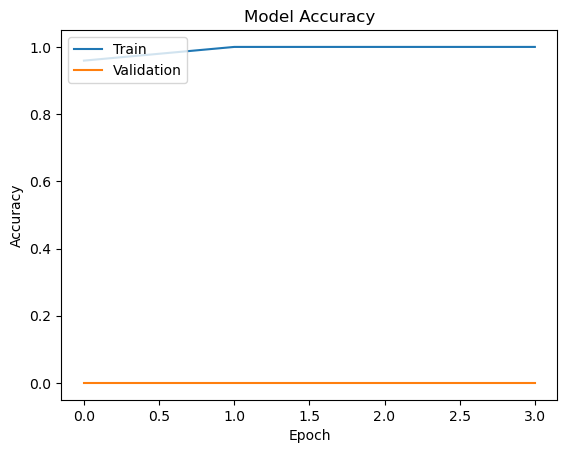

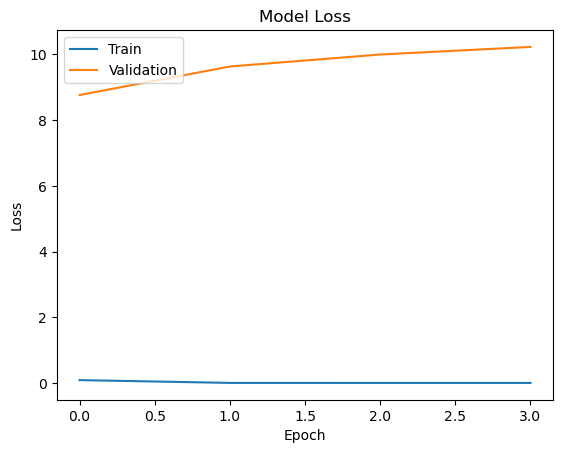

In [26]:
import matplotlib
try:
    import matplotlib.pyplot as plt
except Exception as e:
    print("matplotlib not available — to enable plotting run: '\n'  pip install matplotlib\n  or conda install -c conda-forge matplotlib")
    print("Skipping plots.")
else:
    if 'history' in globals() and hasattr(history, 'history'):
        keys = history.history.keys()
        # Plot accuracy if available
        if 'accuracy' in keys or 'val_accuracy' in keys:
            plt.plot(history.history.get('accuracy', []))
            plt.plot(history.history.get('val_accuracy', []))
            plt.title('Model Accuracy')
            plt.ylabel('Accuracy')
            plt.xlabel('Epoch')
            plt.legend(['Train', 'Validation'], loc='upper left')
            plt.show()
        else:
            print("No accuracy keys found in history; skipping accuracy plot.")

        # Plot loss if available
        if 'loss' in keys or 'val_loss' in keys:
            plt.plot(history.history.get('loss', []))
            plt.plot(history.history.get('val_loss', []))
            plt.title('Model Loss')
            plt.ylabel('Loss')
            plt.xlabel('Epoch')
            plt.legend(['Train', 'Validation'], loc='upper left')
            plt.show()
        else:
            print("No loss keys found in history; skipping loss plot.")
    else:
        print("No 'history' object found in the notebook. Run training to generate history and then re-run this cell to plot results.")

In [ ]:
import json

file_path = "c:\\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\\train.ipynb"

with open(file_path, 'r', encoding='utf-8') as f:
    nb = json.load(f)

for cell in nb['cells']:
    if cell['cell_type'] == 'code':
        source = "".join(cell['source'])
        if "loss, acc = model.evaluate(val_gen, steps=validation_steps, verbose=1)" in source and "model.compile" not in source:
            # We want to insert model.compile before model.evaluate
            new_source = []
            for line in cell['source']:
                if "loss, acc = model.evaluate" in line:
                    new_source.append("model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])\\n\\n")
                new_source.append(line)
            cell['source'] = new_source

with open(file_path, 'w', encoding='utf-8') as f:
    json.dump(nb, f, indent=1)

print("Notebook updated successfully.")


RuntimeError: You must compile your model before training/testing. Use `model.compile(optimizer, loss)`.

In [ ]:

import numpy as np
import os
import cv2

class_names = ['bloody', 'explosions', 'fight', 'gun shot', 'non-violence', 'violence']
SEQ_LEN = 16

def load_clip_sequence(clip_dir, frames=SEQ_LEN):
    frame_files = sorted([
        f for f in os.listdir(clip_dir)
        if f.lower().endswith((".jpg",".jpeg",".png"))
    ])

    if len(frame_files) < frames:
        raise ValueError(f"Not enough frames in {clip_dir}. Found {len(frame_files)}")

    selected = frame_files[:frames]
    frames_data = []

    for f in selected:
        img_path = os.path.join(clip_dir, f)
        img = cv2.imread(img_path)

        if img is None:
            raise ValueError(f"Failed to read {img_path}")

        img = cv2.resize(img, (224, 224))
        img = img.astype("float32") / 255.0
        frames_data.append(img)

    x = np.expand_dims(np.array(frames_data, dtype="float32"), axis=0)
    return x

# CHANGE THIS PATH
clip_dir = r"C:\Users\Shubham\Downloads\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\video_dataset\custom-videos-dataset\train\fight\clip_0026"

x = load_clip_sequence(clip_dir)

pred = seq_model.predict(x, verbose=0)

# Safe handling
if pred.ndim == 3:
    pred = np.mean(pred, axis=1)

pred_class = int(np.argmax(pred, axis=1)[0])

print("Probabilities:", pred)
print("Predicted:", class_names[pred_class])

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\Shubham\\Downloads\\Detection-of-Violent-Scenes-in-Cartoon-Movies-main\\video_dataset\\custom-videos-dataset\\train\\fight\\clip_0026'

In [ ]:
class_names = ['bloody', 'explosions', 'fight', 'gun shot', 'non-violence', 'violence']

if pred.ndim == 3:
    pred = np.mean(pred, axis=1)

predicted_class = int(np.argmax(pred))

print("Probabilities:", pred)
print("Predicted class:", class_names[predicted_class])

Probabilities: [[0.21234159 0.1608241  0.14421195 0.14675963 0.12930793 0.20655479]]
Predicted class: bloody
